In [60]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from torch.utils.data import TensorDataset, DataLoader
import seaborn as sns
import matplotlib.pyplot as plt


In [61]:
df = pd.read_csv("customers.csv")
df.head()


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [62]:
if 'ID' in df.columns:
    df = df.drop('ID', axis=1)
df = df.fillna(method='ffill')


/tmp/ipython-input-1917525315.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


Epoch 10: Loss 1.2164
Epoch 20: Loss 1.2042
Epoch 30: Loss 1.1941
Epoch 40: Loss 1.1918
Epoch 50: Loss 1.1892
Epoch 60: Loss 1.1859
Epoch 70: Loss 1.1806
Epoch 80: Loss 1.1835
Epoch 90: Loss 1.1846
Epoch 100: Loss 1.1812
Test Accuracy: 0.4726507713884993
Confusion Matrix:
 [[186 135 105 158]
 [106 153 149  82]
 [ 52  89 264  67]
 [111  41  33 408]]

Classification Report:

              precision    recall  f1-score   support

           A       0.41      0.32      0.36       584
           B       0.37      0.31      0.34       490
           C       0.48      0.56      0.52       472
           D       0.57      0.69      0.62       593

    accuracy                           0.47      2139
   macro avg       0.46      0.47      0.46      2139
weighted avg       0.46      0.47      0.46      2139



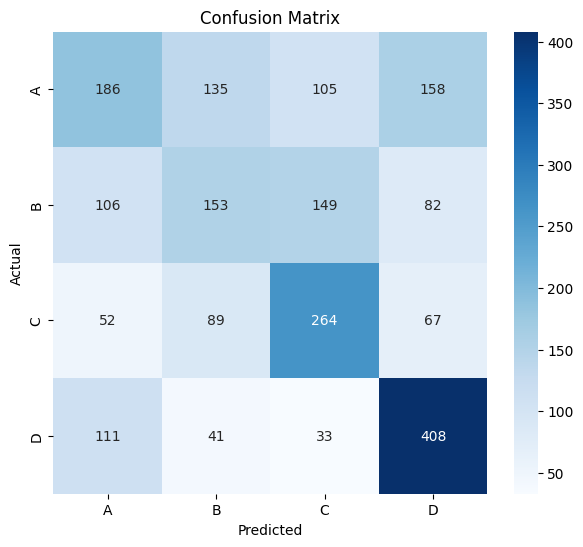


Sample Index: 1110
Predicted: A
Actual: B


In [59]:
le_dict = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le
X = df.drop('Segmentation', axis=1)
y = df['Segmentation']
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train.values)
y_test = torch.LongTensor(y_test.values)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=32)
class PeopleClassifier(nn.Module):
    def __init__(self, input_size):
        super(PeopleClassifier, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 4)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.dropout(F.relu(self.fc3(x)))
        x = self.fc4(x)
        return x
def train_model(model, loader, criterion, optimizer, epochs=100):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for inputs, labels in loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (epoch+1)%10==0:
            print(f"Epoch {epoch+1}: Loss {total_loss/len(loader):.4f}")

model = PeopleClassifier(X_train.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_model(model, train_loader, criterion, optimizer, 100)
model.eval()

all_preds=[]
all_labels=[]

with torch.no_grad():
    for inputs,labels in test_loader:
        outputs=model(inputs)
        _,predicted=torch.max(outputs,1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

# Accuracy
accuracy=np.mean(np.array(all_preds)==np.array(all_labels))
print("Test Accuracy:",accuracy)

# Confusion Matrix
cm=confusion_matrix(all_labels,all_preds)
print("Confusion Matrix:\n",cm)

# Report
print("\nClassification Report:\n")
print(classification_report(all_labels,all_preds,target_names=['A','B','C','D']))

# Heatmap
plt.figure(figsize=(7,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['A','B','C','D'],
            yticklabels=['A','B','C','D'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# -------- Predict One Random Customer --------
labels=['A','B','C','D']
sample_index=np.random.randint(len(X_test))

sample_input=X_test[sample_index].unsqueeze(0)

with torch.no_grad():
    output=model(sample_input)
    pred=torch.argmax(output,1).item()
    actual=y_test[sample_index].item()

print("\nSample Index:",sample_index)
print("Predicted:",labels[pred])
print("Actual:",labels[actual])
